# Cyclophilin D Docking Pose Recapitulation

This notebook is the analysis code for the molecular docking benchmark in *High-Throughput Crystallographic Fragment Screening of Cyclophilin D: A Structural Atlas and Resource for Inhibitor Discovery* (Gebauer *et al.*). It takes the crystallographically resolved fragment poses and the corresponding GNINA docking output and:

1. computes the RMSD of every ranked docked pose to the nearest crystal pose within the same structure (Fig. S3A),
2. asks whether GNINA's pose ranking prioritizes crystallographic poses, and
3. measures how many ligands are recovered within a given RMSD threshold as successively more ranked poses are included.

The main result is that docking recapitulates crystallographic poses poorly for this dataset. The median minimum RMSD oscillates around ~12 Å regardless of pose rank, so the internal ranking provides no meaningful enrichment for the crystal pose, and only a minority of ligands are placed within 3 Å of an experimental pose even when all nine poses are considered. Weakly binding fragments are the hard case for pose prediction, which is the argument for the experimental dataset reported here.

## Approach

- **Docking.** Apo CypD (PDB: 8UC5) was superposed onto chain X of each fragment structure so that all coordinates share a reference frame. Docking was run with GNINA 1.3 using a 27 × 27 × 27 Å³ cubic box centered on the protein (`cnn_center` set to the same coordinate), exhaustiveness 48, seed 0, one fragment per crystal as the ligand, for 438 ligands in total.
- **Atom ordering.** GNINA reorders atoms in its output, which breaks a naive atom-to-atom RMSD. The input SDFs (`ref_mols`) are therefore used as topology references to remap the docking output (`dock_mols`) with RDKit before any RMSD is computed, so each pose is scored against the correct atom mapping.
- **RMSD.** Only heavy atoms are used, because protonation states differ between fragments in the crystal structures. Each crystal structure can contain several binding events, so the value reported for a docked pose is the **minimum RMSD to any crystal pose within that structure**. Two structures (`x0625`, `x0603`) are skipped: tautomer differences change the heavy-atom count and the isomorphism check fails, leaving 436 structures in `dock_df`.
- **Rank evaluation.** `dock_df` holds the minimum RMSD for each of the nine ranked poses per structure. The violin plot compares the distributions across ranks; the stacked histogram shows how the pose ranks contribute across the RMSD range.
- **Cumulative recovery.** For each *N*, the running minimum across poses 1…*N* is taken (`progressive_df`), and the number of ligands falling below a threshold (`MIN_RMSD`, 3 Å in the figure) is counted. The curve is summarized with a normalized AUC so that thresholds can be compared on the same scale.

All dictionaries (`ref_mols`, `dock_mols`, `pdbs`) are keyed by crystal ID (e.g. `x0402`) so that reference topology, docked poses and the crystal complex stay aligned throughout.

## Notebook sections

| Section | What it does |
|---|---|
| Molecular Data Structure Assembly | Loads reference SDFs, GNINA output and superposed crystal complexes from archives, keyed by crystal ID |
| RMSD Database Assembly | Remaps atom order, computes the pose × crystal-pose RMSD matrix per structure, and reduces it to the minimum RMSD per ranked pose (`dock_df`) |
| Evaluating Capacity of GNINA Pose Ranking | Violin plot of minimum RMSD by pose rank, plus a stacked histogram of the RMSD distribution colored by rank |
| Evaluating Cumulative Pose Ranking | Running minimum across the top *N* poses, number and fraction of ligands below the RMSD threshold, and the normalized AUC of that curve |

## Inputs (`data/`)

- `isolated_mols.tar.xz`: fragments as input to GNINA, used only as topology references for atom reordering
- `102825_gnina_docking_results.tar.xz`: GNINA output, nine ranked poses per ligand
- `103025_superposed_mol.tar.xz`: crystal complexes superposed into the docking reference frame

## Outputs

- `processed_data/min_docking_rmsd_per_structure.xlsx`: minimum RMSD per ranked pose per structure
- `final_figures/gnina_min_rmsd_violin_plot.pdf`: RMSD distribution by pose rank
- `final_figures/gnina_rmsd_histogram_by_pose.pdf`: stacked RMSD histogram colored by pose rank
- `final_figures/<threshold>A_nth_pose_inclusion_102825_gnina_docking.pdf`: ligands recovered below threshold as a function of pose inclusion

Helper functions live in the local `utils/` package (`graphs`, `metrics`, `mol`). Docking was run locally on a Lenovo ThinkPad X1 Yoga Gen 5 (Intel Core i5-10210U, 16 GB RAM, Ubuntu 24.04.3 LTS) in roughly 3 h 15 min. The notebook was run with Python 3.10.19 using RDKit, ProDy, pandas, NumPy, Matplotlib and seaborn.

# Data Analysis

In [1]:
%load_ext autoreload
%autoreload 2
import prody as pr
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import io
import numpy as np
import matplotlib.animation as animation

from prody import parsePDB
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from utils.graphs import standardize_graph, cmap_hex, blend_cmap
from utils.mol import (
    load_pdbs_from_archive,
    load_sdfs_from_archive,
    calculate_matrix_in_memory,
)
from utils.metrics import normalized_auc


In [2]:
np.set_printoptions(precision=3, suppress=True, linewidth=120)
pr.confProDy(verbosity="none")  # no
posebusters_cmap = LinearSegmentedColormap.from_list(
    "ai_blend", ["#C99D0B", "#C62828", "#20498D", "#112445"]
)


## Molecular Data Structure Assembly

`ref_mols` is used to correct for gnina altering the atom order of compounds and allow for accurate RMSD calculations

`dock_mols` is the output from the gnina docking 

`pdbs` is the crystal structure complexes 

All are dictionaries labeled by the crystal id i.e. `x0402`

The capture is due to two structures having changes in tautomerization which change the atom count in such a way that does not allow RMSD calculation. Keeps output clean

In [3]:
%%capture
ref_mols = load_sdfs_from_archive(
    Path("./data/isolated_mols.tar.xz"), name_lambda=lambda x: x.split("-")[1]
)
dock_mols = load_sdfs_from_archive(
    Path("./data/102825_gnina_docking_results.tar.xz"),
    name_lambda=lambda x: x.split("_")[1],
)
pdbs = load_pdbs_from_archive(
    Path("data/103025_superposed_mol.tar.xz"), name_lambda=lambda x: x.split("_")[1]
)

In [4]:
print(f"Number of ref_mols : {len(ref_mols)}")
print(f"Number of dock_mols : {len(dock_mols)}")
print(f"Number of PDBs : {len(pdbs)}")

Number of ref_mols : 438
Number of dock_mols : 438
Number of PDBs : 438


## RMSD Database Assembly
With the molecular data structures assembled that contain the reference molecule topologies input into gnina and the output dock molecules, we can now calcualte the RMSDs between all docked poses and all crystal poses within a given xtal ID. 

The molecules input into gnina are required because gnina changes the atom order, and to have accurate RMSDs we use the topology of the input molecule as a reference to reorder the atoms output from GNINA. This ensures that the RMSD for a given pose is mapping the correct atoms to each other. 

`dock_df` contains the minimum RMSD for each ranked pose output by gnina to any crystal pose in the set. 



In [5]:
rmsd_dict = {}
complex_names = list(dock_mols.keys())
# Calculate the pairwise rmsd between each docked molecule
for name in tqdm(complex_names, desc="In-Memory RMSD"):
    try:
        # Pass the molecules directly from your existing dictionaries
        matrix = calculate_matrix_in_memory(name, ref_mols[name], dock_mols[name])
        rmsd_dict[name] = matrix
    except Exception as e:
        print(f"Skipped {name}: {e}")

# Isolate the RMSD to the nearest crystal pose
min_rmsd_dict = dict()
for mol in rmsd_dict.keys():
    min_rmsds = np.min(rmsd_dict[mol], axis=0)
    poses = [f"Pose {i + 1}" for i in range(len(min_rmsds))]
    tmp_dict = dict()
    for pose, min_r in zip(poses, min_rmsds):
        tmp_dict[pose] = min_r

    min_rmsd_dict[mol] = tmp_dict
dock_df = pd.DataFrame.from_dict(min_rmsd_dict, orient="index")
dock_df = dock_df.sort_index()
dock_df = dock_df.round(3)
dock_df.to_excel(f"processed_data/min_docking_rmsd_per_structure.xlsx")
dock_df

In-Memory RMSD:  18%|█▊        | 80/438 [00:00<00:01, 207.64it/s]

Skipped x0625: Topology mismatch (Isomorphism failed)


In-Memory RMSD:  59%|█████▊    | 257/438 [00:01<00:00, 324.18it/s]

Skipped x0603: Topology mismatch (Isomorphism failed)


In-Memory RMSD: 100%|██████████| 438/438 [00:01<00:00, 298.11it/s]


,Pose 1,Pose 2,Pose 3,Pose 4,Pose 5,Pose 6,Pose 7,Pose 8,Pose 9
x0022,9.941,9.754,9.666,5.761,5.717,7.027,1.864,9.891,7.196
x0023,22.689,24.215,23.052,24.379,26.699,27.142,28.850,27.174,24.770
x0029,5.845,4.579,6.713,6.768,24.130,6.563,6.825,23.964,6.179
x0035,19.543,20.280,20.093,20.498,19.978,19.722,4.570,4.525,3.626
x0036,8.070,7.998,20.839,8.538,21.345,26.008,21.133,21.804,22.457
...,...,...,...,...,...,...,...,...,...
x0984,10.665,10.204,10.265,10.620,10.363,20.103,10.454,19.691,19.613
x0985,1.322,20.117,19.005,19.726,24.810,3.465,3.147,19.859,3.697
x0987,20.917,20.772,20.817,20.983,20.542,4.619,21.161,4.321,4.246
x0990,25.901,24.939,26.052,24.879,2.757,20.315,24.611,21.549,3.888


# Evaluating Capacity of Gnina Pose Ranking to Prioritize Crystal Poses

To answer the question as to whether docking can prioritize crystal poses, we construct a violin plot of the minimum RMSD per ranked pose output by gnina.

The median across ranks oscilates around ~12 Angstroms. No significant prioitization observed from this plot

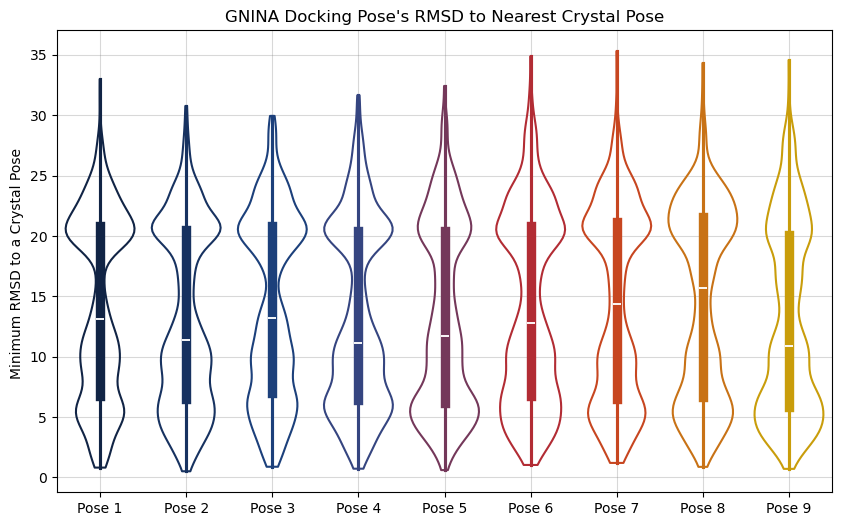

In [6]:
plt.figure(figsize=(10, 6))  # width, height in inches
ax = sns.violinplot(
    data=dock_df,
    palette=[
        posebusters_cmap.reversed()(i) for i in np.linspace(0, 1, len(dock_df.columns))
    ],
    zorder=2,
    fill=False,
    cut=0,
    bw_adjust=0.5,
)

ax.set_ylabel(f"Minimum RMSD to a Crystal Pose ")
ax.grid(c="grey", alpha=0.3, zorder=-5)
ax.set_title(f"GNINA Docking Pose's RMSD to Nearest Crystal Pose")

plt.savefig(f"final_figures/gnina_min_rmsd_violin_plot.pdf", bbox_inches="tight")
plt.show()

/var/folders/th/hb_rdrq56l79hs34cwy2p5pr0000gn/T/ipykernel_56439/1009629530.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), size=11)
/var/folders/th/hb_rdrq56l79hs34cwy2p5pr0000gn/T/ipykernel_56439/1009629530.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), size=11)


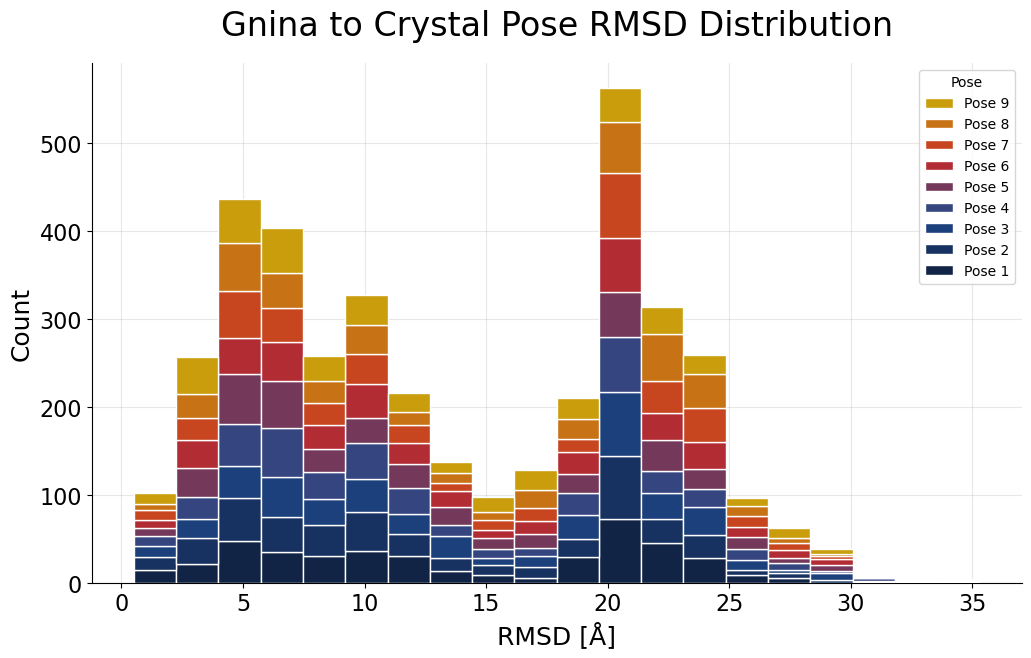

In [7]:
dock_long = dock_df.melt(var_name="Pose", value_name="RMSD")
palette = sns.color_palette(
    posebusters_cmap.reversed()(np.linspace(0, 1, dock_long["Pose"].nunique()))
)[::-1]
fig, ax = plt.subplots(figsize=(16 * 0.75, 9 * 0.75))

sns.histplot(
    data=dock_long.iloc[::-1],
    x="RMSD",
    hue="Pose",
    multiple="stack",
    palette=palette,
    edgecolor="white",
    alpha=1,
    ax=ax,
    zorder=10,
)
ax.set_title(f"Gnina to Crystal Pose RMSD Distribution", fontdict={"size": 16}, pad=15)
ax.set_xlabel(f"RMSD [Å]", fontdict={"size": 12})
ax.set_ylabel(f"Count", fontdict={"size": 12})
ax.set_xticklabels(ax.get_xticklabels(), size=11)
ax.set_yticklabels(ax.get_yticklabels(), size=11)
ax.grid(alpha=0.3, zorder=-1)
standardize_graph(ax)
sns.despine()

fig.savefig(f"./final_figures/gnina_rmsd_histogram_by_pose.pdf", bbox_inches="tight")

## Evaluating Capacity of Cumulatitive Gnina Pose Ranking to Prioritize Crystal Poses

We see that the individual pose rankings by themselves do not sigificantly reduce the median RMSD.

Alternately we ask the question, what if you take the top N poses, what is the fraction that are below a given RMSD threshold. This next section address that:

In [8]:
progressive_min = {}
for i in range(dock_df.shape[1]):
    subset = dock_df.iloc[:, : i + 1]
    progressive_min[f"Pose 1-{i + 1}"] = subset.min(axis=1)

progressive_df = pd.DataFrame(progressive_min)

# melt for seaborn
progressive_long = progressive_df.melt(var_name="Pose Range", value_name="Min RMSD")
progressive_long

,Pose Range,Min RMSD
0,Pose 1-1,9.941
1,Pose 1-1,22.689
2,Pose 1-1,5.845
3,Pose 1-1,19.543
4,Pose 1-1,8.070
...,...,...
3919,Pose 1-9,10.204
3920,Pose 1-9,1.322
3921,Pose 1-9,4.246
3922,Pose 1-9,2.757


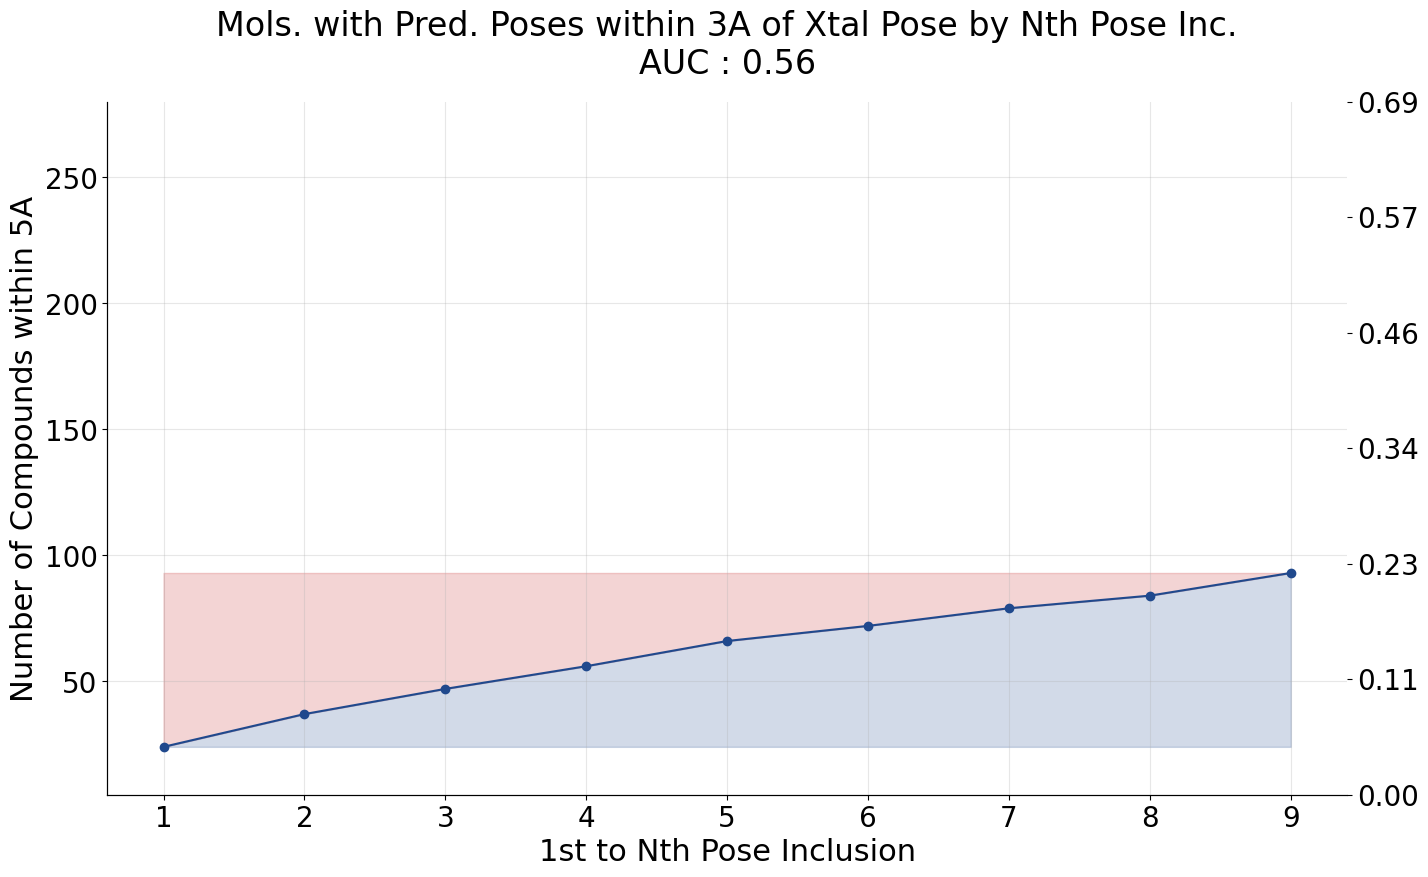

In [9]:
MIN_RMSD = 3
n_below = []
fracs = []
pose_order = sorted(progressive_long["Pose Range"].unique())
for pose in pose_order:
    tmp_data = progressive_long[progressive_long["Pose Range"] == pose]
    n_below_thresh = len(tmp_data[tmp_data["Min RMSD"] < MIN_RMSD])
    # Protect against division by zero just in case a pose bin is empty
    frac = round(n_below_thresh / len(tmp_data), 2) if len(tmp_data) > 0 else 0.0

    n_below.append(n_below_thresh)
    fracs.append(frac)


fig, ax = plt.subplots(figsize=(16, 9))
x_vals = [i + 1 for i in range(len(n_below))]
ax.plot(x_vals, n_below, marker="o", c=cmap_hex["blue"])
ax.grid(alpha=0.2)

ax.set_xlabel(f"1st to Nth Pose Inclusion")

ax.set_ylabel(f"Number of Compounds within 5A")
ax.set_ylim(5, 280)
max_ref = 436
ax2 = ax.twinx()
ymin = ax.get_ylim()[0]
ymin = ax.get_ylim()[0]
ax.fill_between(x_vals, n_below, min(n_below), color=cmap_hex["blue"], alpha=0.2)
ax.fill_between(x_vals, n_below, max(n_below), color=cmap_hex["red"], alpha=0.2)
ax2.set_ylim(ax.get_ylim())
y_ticks = ax.get_yticks()
ax2.set_yticks(y_ticks)
ax2.set_yticklabels([f"{y / max_ref:.2f}" for y in y_ticks])
ax2.tick_params(axis="y", colors="black")

auc = round(normalized_auc([i for i in range(len(n_below))], n_below), 2)

sns.despine()
ax.set_title(
    f"Mols. with Pred. Poses within {MIN_RMSD}A of Xtal Pose by Nth Pose Inc.\nAUC : {auc}"
)
standardize_graph(ax, title_size=24, tick_size=20, label_size=22)

fig.savefig(
    f"./final_figures/{MIN_RMSD}A_nth_pose_inclusion_102825_gnina_docking.pdf",
    format="pdf",
)